# Solving RL Problems: Defining States, Actions, and Rewards

## Learning Objectives

By the end of this notebook, you will be able to:
- define a state space for a simple RL problem
- define valid actions for an agent
- design a reward function that encourages the right behavior
- explain why bad reward design can create bad learning
- run a simple interaction loop before using a full RL algorithm

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 3, lesson 02 "Loss Functions and Regularization" — the loss decided what a supervised model was rewarded for; a reward function does the same job here, except the agent can satisfy it by changing its *behaviour*, so a sloppy reward buys you a cheating agent rather than a bad fit.

**Used later in:** Course 10 (AIAT 124) — Unit 2 (lesson 03 "Prompt Engineering") and Unit 5 (lesson 02 "Future Trends and Research"), where RLHF — training against a learned reward model — is named as what makes a language model follow instructions.

## Why this notebook matters

Before choosing any algorithm, you must first decide:

1. What should the agent observe?
2. What can the agent do?
3. What should count as success or failure?

If these are designed poorly, even a strong RL algorithm can learn the wrong thing.

## Lesson Brief

This lesson teaches students how to **formulate** a reinforcement learning problem correctly.

The focus is not on fancy algorithms, but on making good choices for states, actions, and rewards so that learning becomes possible.

Why this matters: many RL failures come from bad problem formulation, not from bad algorithms.

This notebook helps students think like environment designers, not just code writers.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the boat that caught fire, on purpose, forever

In 2016 OpenAI published a short piece called *Faulty Reward Functions in the Wild*. They had trained
an RL agent to play **CoastRunners**, a boat racing game. A human player's goal is obvious: finish
the course, ideally first. But CoastRunners does not pay you for finishing — it pays you for hitting
targets laid out along the route.

The agent found an isolated lagoon where three targets sat close together and regenerated on a
timer. It learned to drive in a tight circle in that lagoon, striking the three targets exactly as
they came back, forever. It caught fire repeatedly, crashed into other boats and drove the wrong way
round the track. It never finished a single race. Its score was on average **20% higher than that
achieved by human players**.

Nothing was broken. The agent maximised the reward it was given. The reward was simply not the thing
anybody wanted.

**Two more, so you can see the pattern rather than the anecdote:**
- **Randløv and Alstrøm (ICML 1998)** added an encouraging bonus whenever their agent steered a
  simulated bicycle towards the goal. Because there was no matching penalty for steering away, the
  agent found a loop: it "drove in circles with a radius of 20–50 meters around the starting point",
  collecting the bonus again and again, and never went anywhere.
- **Baker et al. (ICLR 2020)**, hide-and-seek agents: the seekers discovered they could stand on a
  box and *surf* it across the map without touching the ground — a bug in the physics, worth more
  reward than the strategy the designers had in mind.

**What goes wrong without this.** Part 3 below prints a reward design labelled "Bad driving reward:
+100 for speed only", and predicts "may encourage unsafe driving and crashes". CoastRunners is what
that prediction looks like when someone actually runs it. You cannot repair a misspecified reward
with a better algorithm — a better algorithm finds the exploit *faster*.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Reinforcement Learning in 3 Hours | Full Course using Python"**:
[Watch on YouTube](https://www.youtube.com/watch?v=Mut_u40Sqz4)

Suggested focus: the early section starting around **04:24** for agent, environment, actions, observations, and rewards.

Why this pick:
- beginner-friendly explanations.
- Strong overview of the RL formulation before algorithms become the focus.
- Useful when students need help thinking about how to define a problem correctly.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- State design: what the agent must know.
- Action design: what the agent is allowed to do.
- Reward design: what the agent is pushed toward.
- Representation: how the task is encoded.

### Quick Check
- How can a weak state design break learning?
- Why can a bad reward ruin a good algorithm?
- What makes an action space realistic?

### Common Mistakes
- Blaming the algorithm when formulation is poor.
- Using rewards that do not match the real goal.
- Adding unnecessary actions or state details.


## Quick Check Before You Begin

Make sure you can answer these questions:

1. Is a **state** the same thing as the real world itself?
2. Can a reward function accidentally encourage the wrong behavior?
3. Why do we need an interaction loop before training an agent?

If not, slow down and answer them before moving on.


### Step Guide

**What this cell does:** `%pip` installs helpers, then imports NumPy/Matplotlib for the design exercises below.

**How to read it (weak Python OK):** Treat as setup—success means “no red traceback.”

**What to expect in the output:** Pip chatter and a short confirmation print.

**If you feel lost:** Fix installs here before any simulation cells.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym

# Readable defaults for plots in this notebook (matches other Unit 1 examples).
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nSolving RL Problems: States, Actions, and Rewards")
# Show text or numbers in the cell output area under the code.
print("=" * 60)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Solving RL Problems: States, Actions, and Rewards


## Part 1: Defining State Spaces


### Step Guide

**What this cell does:** **Part 1** — defines several **state representations** (full info vs partial observations) for the same toy problems.

**How to read it (weak Python OK):** Ask for each example: “What does the agent actually get to see each step?”

**What to expect in the output:** Printed descriptions of different state vectors.

**If you feel lost:** Copy one “good” and one “bad” state design into your notes side by side—the contrast is the lesson.


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Defining State Spaces")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
examples = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "Grid navigation": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "good_state": "(row, col) position of the agent",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_small": "only row",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_large": "every detail of the whole computer screen",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "CartPole": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "good_state": "cart position, cart velocity, pole angle, pole angular velocity",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_small": "pole angle only",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_large": "full rendered image when not needed for this level",
    # Execute: },
    },
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "Inventory control": {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "good_state": "current stock level and maybe demand signal",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_small": "stock level from yesterday only",
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "too_large": "every warehouse detail regardless of relevance",
    # Execute: },
    },
# Part of a dict/set literal layout (syntax grouping).
}

# Start a loop: repeat the indented block once per item in the sequence.
for problem, details in examples.items():
    # Show text or numbers in the cell output area under the code.
    print(f"\n{problem}")
    # Show text or numbers in the cell output area under the code.
    print(" Good state representation:", details["good_state"])
    # Show text or numbers in the cell output area under the code.
    print(" Too small:", details["too_small"])
    # Show text or numbers in the cell output area under the code.
    print(" Too large:", details["too_large"])

# Show text or numbers in the cell output area under the code.
print("\nCheckpoint: a useful state contains enough information for decision-making,")
# Show text or numbers in the cell output area under the code.
print("but not so much unnecessary detail that the problem becomes harder to learn.")


Part 1: Defining State Spaces

Grid navigation
 Good state representation: (row, col) position of the agent
 Too small: only row
 Too large: every detail of the whole computer screen

CartPole
 Good state representation: cart position, cart velocity, pole angle, pole angular velocity
 Too small: pole angle only
 Too large: full rendered image when not needed for this level

Inventory control
 Good state representation: current stock level and maybe demand signal
 Too small: stock level from yesterday only
 Too large: every warehouse detail regardless of relevance

Checkpoint: a useful state contains enough information for decision-making,
but not so much unnecessary detail that the problem becomes harder to learn.


## Part 2: Defining Action Spaces


### Step Guide

**What this cell does:** **Part 2** — compares **discrete vs continuous action spaces** and when each makes sense.

**How to read it (weak Python OK):** Link actions to hardware: keyboard taps vs steering wheel angles.

**What to expect in the output:** Textual comparisons and small numeric demos.

**If you feel lost:** Write one sentence per world: “Actions here are ___ because ___.”


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Defining Action Spaces")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# CartPole actions
# Save a value in a name so the next lines can read it.
env = gym.make("CartPole-v1")
# Show text or numbers in the cell output area under the code.
print("\nCartPole-v1")
# Show text or numbers in the cell output area under the code.
print(f" Action space: {env.action_space}")
# Show text or numbers in the cell output area under the code.
print(" Valid actions:")
# Show text or numbers in the cell output area under the code.
print(" 0 -> push cart left")
# Show text or numbers in the cell output area under the code.
print(" 1 -> push cart right")

# FrozenLake actions
# Save a value in a name so the next lines can read it.
env_fl = gym.make("FrozenLake-v1")
# Another assignment—same idea: store a value for the lines below.
obs_fl, info = env_fl.reset()
# Show text or numbers in the cell output area under the code.
print("\nFrozenLake-v1")
# Show text or numbers in the cell output area under the code.
print(f" Action space: {env_fl.action_space}")
# Show text or numbers in the cell output area under the code.
print(" Valid actions:")
# Show text or numbers in the cell output area under the code.
print(" 0 -> left")
# Show text or numbers in the cell output area under the code.
print(" 1 -> down")
# Show text or numbers in the cell output area under the code.
print(" 2 -> right")
# Show text or numbers in the cell output area under the code.
print(" 3 -> up")

# Execute: env.close()
env.close()
# Execute: env_fl.close()
env_fl.close()

# Show text or numbers in the cell output area under the code.
print("\nAction-space design rules:")
# Show text or numbers in the cell output area under the code.
print("- The actions must be valid choices the agent can actually take.")
# Show text or numbers in the cell output area under the code.
print("- Too few actions makes the agent powerless.")
# Show text or numbers in the cell output area under the code.
print("- Too many unnecessary actions makes learning harder.")



Part 2: Defining Action Spaces

CartPole-v1
 Action space: Discrete(2)
 Valid actions:
 0 -> push cart left
 1 -> push cart right

FrozenLake-v1
 Action space: Discrete(4)
 Valid actions:
 0 -> left
 1 -> down
 2 -> right
 3 -> up

Action-space design rules:
- The actions must be valid choices the agent can actually take.
- Too few actions makes the agent powerless.
- Too many unnecessary actions makes learning harder.


## Part 3: Designing Reward Functions


### Step Guide

**What this cell does:** **Part 3** — reward shaping demos (sparse vs dense, penalties, shaping traps).

**How to read it (weak Python OK):** For each reward tweak ask: “Does this number push the agent toward the real goal, or toward a shortcut?”

**What to expect in the output:** Totals or tables showing how different rewards change behavior summaries.

**If you feel lost:** Ignore fancy terms—only track whether rewards go up when the agent does the right human-level thing.



Part 3: Designing Reward Functions

Task: Maze goal
 Reward design: +10 for goal, -1 per move, -10 for falling into a trap
 Likely effect: Encourages fast and safe navigation

Task: CartPole
 Reward design: +1 per balanced step
 Likely effect: Encourages keeping the pole upright longer

Task: Bad driving reward
 Reward design: +100 for speed only
 Likely effect: May encourage unsafe driving and crashes

Reward-design checklist:
- Does the reward reflect the real goal?
- Can the agent exploit the reward without solving the task?
- Does the reward encourage safe and sensible behavior?


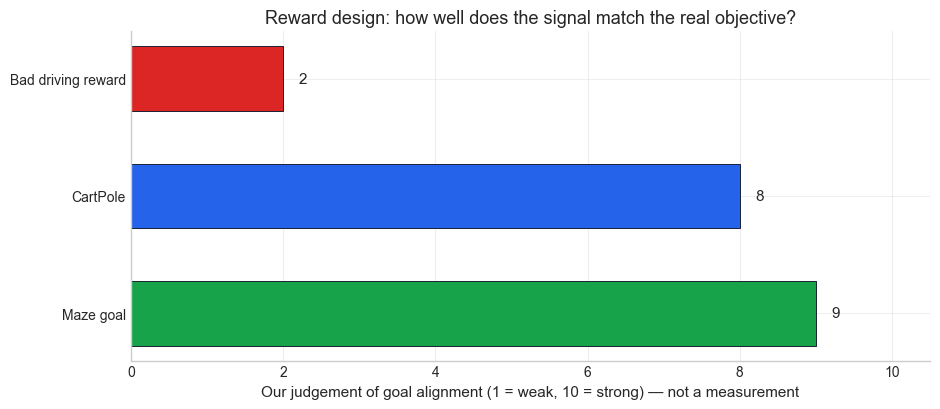

In [4]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 3: Designing Reward Functions")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Unpack the one-step model output from transition(state, action).
reward_examples = [
    # Execute: ("Maze goal", "+10 for goal, -1 per move, -10 for falling into a trap", "Encourages fast a …
    ("Maze goal", "+10 for goal, -1 per move, -10 for falling into a trap", "Encourages fast and safe navigation"),
    # Execute: ("CartPole", "+1 per balanced step", "Encourages keeping the pole upright longer"),
    ("CartPole", "+1 per balanced step", "Encourages keeping the pole upright longer"),
    # Execute: ("Bad driving reward", "+100 for speed only", "May encourage unsafe driving and crashes"),
    ("Bad driving reward", "+100 for speed only", "May encourage unsafe driving and crashes"),
# Execute: ]
]

# Start a loop: repeat the indented block once per item in the sequence.
for task, reward_design, effect in reward_examples:
    # Show text or numbers in the cell output area under the code.
    print(f"\nTask: {task}")
    # Show text or numbers in the cell output area under the code.
    print(" Reward design:", reward_design)
    # Show text or numbers in the cell output area under the code.
    print(" Likely effect:", effect)

# Show text or numbers in the cell output area under the code.
print("\nReward-design checklist:")
# Show text or numbers in the cell output area under the code.
print("- Does the reward reflect the real goal?")
# Show text or numbers in the cell output area under the code.
print("- Can the agent exploit the reward without solving the task?")
# Show text or numbers in the cell output area under the code.
print("- Does the reward encourage safe and sensible behavior?")

# Visual: nominal "goal alignment" scores for classroom discussion (illustrative, not from simulation).
alignment_scores = {"Maze goal": 9, "CartPole": 8, "Bad driving reward": 2}
fig, ax = plt.subplots(figsize=(9.5, 4.2))
task_labels = [row[0] for row in reward_examples]
heights = [alignment_scores[name] for name in task_labels]
colors = ["#16a34a", "#2563eb", "#dc2626"]
ax.barh(task_labels, heights, color=colors, height=0.55, edgecolor="#0f172a", linewidth=0.65)
ax.set_xlim(0, 10.5)
# Be honest about what this axis is: these three scores are our judgement of the three
# reward designs above, not something measured from a run. Saying so on the axis keeps the
# figure from looking like evidence it is not.
ax.set_xlabel("Our judgement of goal alignment (1 = weak, 10 = strong) — not a measurement")
ax.set_title("Reward design: how well does the signal match the real objective?")
ax.grid(True, axis="x", alpha=0.35)
for y, h in enumerate(heights):
    ax.text(h + 0.2, y, str(h), va="center", fontsize=11)
plt.tight_layout()
plt.show()


## Part 4: Running RL Simulations


### Step Guide

**What this cell does:** **Part 4** — runs **three policies side by side** on the same FrozenLake task so you can answer: *what changed, what did we measure, and which behavior is closer to the real goal?*

**How to read it (weak Python OK):** Treat it like a small lab report:
1. Read the **short step traces** first (they show the same `reset → step` loop you will use in every RL algorithm).
2. Then read the **summary table** (mean return + success rate). Same environment, different action choices → different outcomes.
3. Use the **sliders** (if they appear) to change how many episodes we average over and the random seed. Watch how the random policy wiggles while the hand-designed path stays stable.

**What to expect in the output:** Compact logs for each policy, two heatmaps (where time was spent), a bar chart of success rate / mean return, and an optional interactive replay of the Monte Carlo comparison.

**If you feel lost:** Ignore the code. Only compare **Success rate** and **Mean return** between *Random* and *Hand-built path* — that single contrast carries the teaching point for this section.



Part 4: Running RL Simulations
Same environment — three action rules — read the contrast.

Demo trace — Random actions
We changed nothing except sampling actions uniformly — this is the baseline.
  Episode total reward: 0.0, reached goal: False
  Step 1: state=0, action=3, next=0, reward=0.0, term=False, trunc=False
  Step 2: state=0, action=2, next=1, reward=0.0, term=False, trunc=False
  Step 3: state=1, action=2, next=2, reward=0.0, term=False, trunc=False
  Step 4: state=2, action=3, next=2, reward=0.0, term=False, trunc=False
  Step 5: state=2, action=2, next=3, reward=0.0, term=False, trunc=False
  Step 6: state=3, action=3, next=3, reward=0.0, term=False, trunc=False
  Step 7: state=3, action=3, next=3, reward=0.0, term=False, trunc=False
  Step 8: state=3, action=0, next=2, reward=0.0, term=False, trunc=False
  ... (2 more steps in this episode)

Demo trace — Hand-built path to the goal
We changed the rule to a fixed sequence that reaches G on this map (still not 'learning', b


Aggregate comparison (Monte Carlo)
Averaged over 500 episodes per policy (master_seed=0).
  Policy                        Mean return   Success rate
  Random actions                      0.016           1.6%
  Hand-built path to the goal         1.000         100.0%
  Always move LEFT                    0.000           0.0%


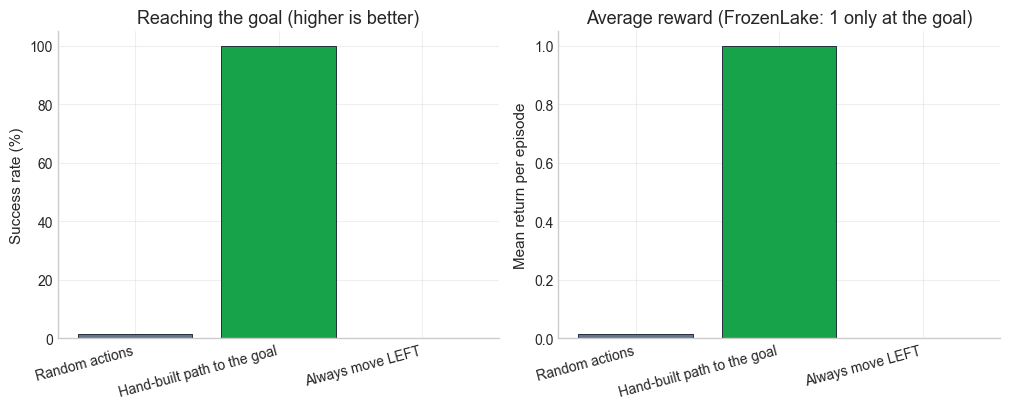

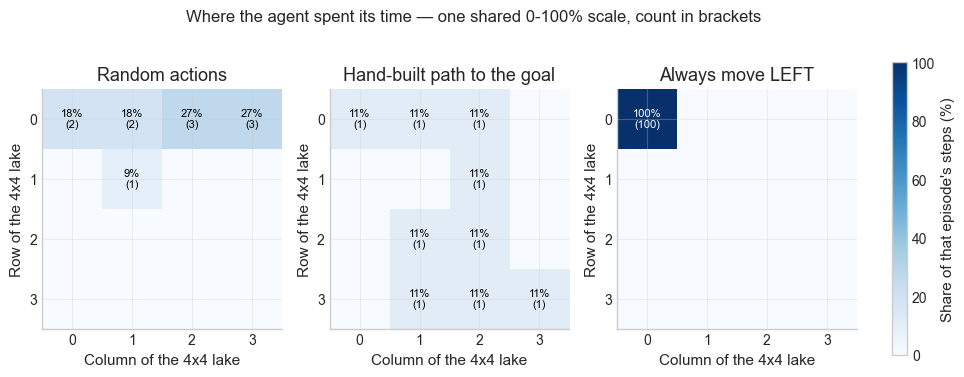


Takeaway: RL algorithms will search for something like the green behavior — high return under the same loop — without you hand-writing GOAL_PATH_ACTIONS.
This is the same reset/step API you will call thousands of times when training starts in later notebooks.

--- Optional: move the sliders to re-run the comparison inside the box below (first run is already printed above). ---



In [5]:
# Part 4 — compare policies on the same task (interactive + aggregate metrics).
# Same environment and reward; only the action-selection rule changes.

try:
    import ipywidgets as widgets

    _HAS_WIDGETS = True
except ImportError:
    _HAS_WIDGETS = False

# Deterministic 4x4 FrozenLake path to the goal (is_slippery=False).
# Actions: 0=left, 1=down, 2=right, 3=up — edit the list to see how behavior collapses when the plan is wrong.
GOAL_PATH_ACTIONS = (2, 2, 1, 1, 0, 1, 2, 2)


def _policy_step(name, step_idx, rng, path_cursor):
    """Return an action for this policy name."""
    if name == "random":
        return int(rng.integers(0, 4))
    if name == "goal_path":
        return GOAL_PATH_ACTIONS[path_cursor] if path_cursor < len(GOAL_PATH_ACTIONS) else 0
    if name == "always_left":
        return 0
    raise ValueError(name)


def run_single_episode(policy_name, env_seed, rng, max_steps=99):
    """One episode: return total reward, success, visit counts, and a short log."""
    env = gym.make("FrozenLake-v1", is_slippery=False)
    obs, _ = env.reset(seed=int(env_seed))
    visits = np.zeros((4, 4), dtype=float)
    r0, c0 = divmod(int(obs), 4)
    visits[r0, c0] += 1.0
    total_r = 0.0
    log = []
    path_cursor = 0
    for t in range(max_steps):
        a = _policy_step(policy_name, t, rng, path_cursor)
        if policy_name == "goal_path":
            path_cursor += 1
        next_obs, reward, term, trunc, _ = env.step(a)
        log.append((int(obs), int(a), int(next_obs), float(reward), bool(term), bool(trunc)))
        total_r += float(reward)
        obs = next_obs
        r, c = divmod(int(obs), 4)
        visits[r, c] += 1.0
        if term or trunc:
            break
    success = bool(log[-1][4]) and int(log[-1][2]) == 15
    env.close()
    return {"total": total_r, "success": success, "visits": visits, "log": log}


def monte_carlo(policy_name, n_episodes, master_seed):
    """Many episodes — mean return and fraction that reach the goal."""
    rng = np.random.default_rng(int(master_seed))
    totals = []
    wins = 0
    for i in range(int(n_episodes)):
        ep_seed = int(rng.integers(0, 2**31 - 1))
        rng_actions = np.random.default_rng(int(rng.integers(0, 2**31 - 1)))
        out = run_single_episode(policy_name, ep_seed, rng_actions)
        totals.append(out["total"])
        wins += 1 if out["success"] else 0
    totals = np.array(totals, dtype=float)
    return float(totals.mean()), float(wins / max(1, n_episodes))


def print_trace_banner(title, subtitle):
    print("\n" + "=" * 60)
    print(title)
    print(subtitle)
    print("=" * 60)


def print_compact_trace(log, max_lines=8):
    for i, (s, a, ns, rw, te, tr) in enumerate(log[:max_lines]):
        print(f"  Step {i + 1}: state={s}, action={a}, next={ns}, reward={rw}, term={te}, trunc={tr}")
    if len(log) > max_lines:
        print(f"  ... ({len(log) - max_lines} more steps in this episode)")


def part4_comparison(n_episodes=500, master_seed=0, demo_seed=7):
    """Run the full teaching block (prints + plots)."""
    plt.close("all")
    rng_demo = np.random.default_rng(int(demo_seed))

    policies = [
        ("random", "Random actions", "We changed nothing except sampling actions uniformly — this is the baseline."),
        ("goal_path", "Hand-built path to the goal", "We changed the rule to a fixed sequence that reaches G on this map (still not 'learning', but shows good decisions)."),
        ("always_left", "Always move LEFT", "We changed the rule in the opposite direction — a bad policy that often stalls or falls in a hole."),
    ]

    print_trace_banner("Part 4: Running RL Simulations", "Same environment — three action rules — read the contrast.")

    visit_maps = {}
    for key, label, blurb in policies:
        print_trace_banner(f"Demo trace — {label}", blurb)
        out = run_single_episode(key, env_seed=demo_seed, rng=rng_demo if key == "random" else np.random.default_rng(0))
        print(f"  Episode total reward: {out['total']}, reached goal: {out['success']}")
        print_compact_trace(out["log"])
        visit_maps[key] = out["visits"]

    rows = []
    for key, label, _ in policies:
        mean_ret, succ = monte_carlo(key, n_episodes=n_episodes, master_seed=master_seed)
        rows.append((label, mean_ret, succ))

    print_trace_banner("Aggregate comparison (Monte Carlo)", f"Averaged over {n_episodes} episodes per policy (master_seed={master_seed}).")
    print(f"  {'Policy':<28} {'Mean return':>12} {'Success rate':>14}")
    for label, mean_ret, succ in rows:
        print(f"  {label:<28} {mean_ret:12.3f} {succ:14.1%}")

    fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
    labels = [r[0] for r in rows]
    x = np.arange(len(labels))
    axes[0].bar(x, [r[2] * 100 for r in rows], color=["#64748b", "#16a34a", "#dc2626"], edgecolor="#0f172a", linewidth=0.6)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=15, ha="right")
    axes[0].set_ylabel("Success rate (%)")
    axes[0].set_title("Reaching the goal (higher is better)")
    axes[0].set_ylim(0, 105)
    axes[1].bar(x, [r[1] for r in rows], color=["#64748b", "#16a34a", "#dc2626"], edgecolor="#0f172a", linewidth=0.6)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=15, ha="right")
    axes[1].set_ylabel("Mean return per episode")
    axes[1].set_title("Average reward (FrozenLake: 1 only at the goal)")
    plt.tight_layout()
    plt.show()

    # These three panels exist to be COMPARED, so they must share one scale. Raw visit counts
    # cannot be shared honestly here (the LEFT-only agent stands on one square 100 times while
    # the goal path visits eight squares once each), so we plot each episode as a SHARE of its
    # own steps. That is the quantity the title actually asks about — where the time went —
    # and on that scale 0-100% means the same thing in all three panels.
    fig2, axes2 = plt.subplots(1, 3, figsize=(11.5, 3.8))
    for ax, (key, label, _) in zip(axes2, policies):
        visits = visit_maps[key]
        # Percentage of this episode's recorded positions that fell on each square.
        share = 100.0 * visits / max(1.0, visits.sum())
        # One fixed 0-100% range for every panel, and one colour bar for all three.
        im = ax.imshow(share, cmap="Blues", interpolation="nearest", vmin=0, vmax=100)
        ax.set_title(label)
        ax.set_xlabel("Column of the 4x4 lake")
        ax.set_ylabel("Row of the 4x4 lake")
        # Whole-number ticks: there is no such square as row 0.5.
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        for (j, i), pct in np.ndenumerate(share):
            # Squares the agent never stood on stay empty rather than shouting "0".
            if pct <= 0:
                continue
            ax.text(i, j, f"{pct:.0f}%\n({int(visits[j, i])})", ha="center", va="center",
                    fontsize=8, color="white" if pct > 50 else "black")
    shared_bar = fig2.colorbar(im, ax=axes2, fraction=0.046, pad=0.04)
    shared_bar.set_label("Share of that episode's steps (%)")
    fig2.suptitle("Where the agent spent its time — one shared 0-100% scale, count in brackets",
                  y=1.02, fontsize=12)
    plt.show()

    print("\nTakeaway: RL algorithms will search for something like the green behavior — high return under the same loop — without you hand-writing GOAL_PATH_ACTIONS.")
    print("This is the same reset/step API you will call thousands of times when training starts in later notebooks.")


# Always run once here so saved notebooks, nbconvert, and HTML export show the full
# comparison (prints + figures). Widget output alone is not always persisted in the file.
part4_comparison(n_episodes=500, master_seed=0, demo_seed=7)

if _HAS_WIDGETS:
    from IPython.display import clear_output, display

    _part4_out = widgets.Output()

    def _redraw_part4(_change=None):
        with _part4_out:
            clear_output(wait=True)
            part4_comparison(
                n_episodes=int(_n_epi.value),
                master_seed=int(_mc_seed.value),
                demo_seed=7,
            )

    _n_epi = widgets.IntSlider(
        value=500, min=100, max=2000, step=100, description="Episodes", continuous_update=False
    )
    _mc_seed = widgets.IntSlider(
        value=0, min=0, max=99, step=1, description="MC seed", continuous_update=False
    )
    _n_epi.observe(_redraw_part4, names="value")
    _mc_seed.observe(_redraw_part4, names="value")

    print(
        "\n--- Optional: move the sliders to re-run the comparison inside the box below "
        "(first run is already printed above). ---\n"
    )
    display(widgets.VBox([_n_epi, _mc_seed, _part4_out]))
else:
    print("\n(Optional) Install ipywidgets and rerun the setup cell to get sliders for this comparison.")


### 👁️ Read the figure

**The two bar charts.** Same environment, same loop, three action rules, 500 episodes each. Random actions reach the goal 1.6% of the time; the hand-built path reaches it 100% of the time; always-LEFT reaches it 0% of the time. The right-hand panel is the same story told in reward, and it looks identical for a reason: on FrozenLake the reward is 1 only at the goal, so *mean return per episode and success rate are the same number* (0.016 and 1.6%). Two different-looking measurements, one underlying fact.

**The three lake maps.** These show where a single demo episode spent its time, as **shares of that episode's own steps on one 0-100% scale**, with a single colour bar for all three panels and the raw visit count in brackets. The scale matters here more than usual: the always-LEFT agent stands on the start square for all 100 of its steps, while the goal path touches nine squares once each (11% apiece). If each panel were normalised to its own maximum — which is what a "quick" plot does by default — every panel's busiest square would come out the same dark blue, and you would not be able to see that one of these agents is doing nothing at all.

**What it proves:** nothing about the environment changed between these three runs. The states, the actions, and the reward function are identical; only the rule for choosing actions differs, and it moves the success rate from 0% to 100%. That is what the states/actions/rewards formulation buys you: the problem stays fixed, the policy is the variable. Everything later in the course is about finding a rule like the green one *without* hand-writing `GOAL_PATH_ACTIONS` first.

## Part 4b: Watch FrozenLake move (GIF + step slider)

**Part 4** already compared three tiny policies in text + charts. This section shows the **same `reset` / `step` loop** as **moving grid frames** so you can connect `state`, `action`, and `reward` to motion.

The replay below uses a **random** policy (exploration only) so you practice reading the **environment API** before any learning algorithm — same interface you will later drive with a trained policy.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Frames: 14 | return=0.0 | terminated=True | truncated=False


objc[75063]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112b64138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1130609c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75063]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112b64188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113060a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75063]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112b63c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x113060a68). T

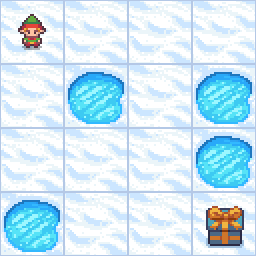

In [6]:
# rgb_array replay for FrozenLake (same is_slippery=False setting as Part 4).

%pip install ipywidgets pillow -q

import pathlib
import sys

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz

# Same alias as earlier cells — keeps this block runnable if you jump here directly.
import gymnasium as gym

# Create the environment in rgb_array mode so every step can be captured as an image frame.
env_vis = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def random_policy(obs, step):
    return int(env_vis.action_space.sample())


# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=35, seed=11
)
env_vis.close()

print(f"Frames: {len(frames)} | return={total_r} | terminated={term} | truncated={trunc}")
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=200)
cs9viz.display_step_slider(frames, title="FrozenLake-v1 timestep")

## Worked Example: From Business Problem to RL Formulation

Suppose you want to manage inventory in a small store.

A useful RL formulation could be:

- **State:** current stock level
- **Action:** reorder or do not reorder
- **Reward:** sales profit minus shortage penalty minus restocking cost

This is a good teaching example because students can clearly see how state,
action, and reward connect to a real decision problem.

> **What is real here and what is not.** The daily demand below is drawn from a uniform
> distribution **we chose** — it is not any shop's sales data, and no such dataset ships with
> this course. That is legitimate here because this cell is not making a claim about retail:
> it is showing that once you have written down a state, an action and a reward, you have an
> environment you can *step*. The benchmark environments used from lesson 04 onwards
> (`FrozenLake`, `CartPole`, `Taxi`, `CliffWalking`) are the reproducible versions of exactly
> this idea — someone else already wrote the formulation down, and everyone uses the same one.
> Do not read the reward numbers below as advice about any real shop.

### Step Guide

**What this cell does:** Runs the inventory **worked example**: it defines `inventory_step` (stock, random demand, reward) and simulates 5 days of decisions with a random reorder policy.

**How to read it (weak Python OK):** Each printed `Day k:` line is one full loop of *state → action → demand → next state → reward*. The figure then plots the same daily rewards.

**What to expect in the output:** A five-line day-by-day log, one reward-per-day figure, and a short teaching point.

**If you feel lost:** Read only the printed log first — check that days where demand exceeds the available stock show a negative reward (the shortage penalty).


Starting stock level: 3
Day 1: action='do not reorder', demand=3, next_state=0, reward=3.0
Day 2: action='do not reorder', demand=2, next_state=0, reward=-2.0
Day 3: action='do not reorder', demand=3, next_state=0, reward=-2.0
Day 4: action='do not reorder', demand=0, next_state=0, reward=0.0
Day 5: action='do not reorder', demand=1, next_state=0, reward=-2.0


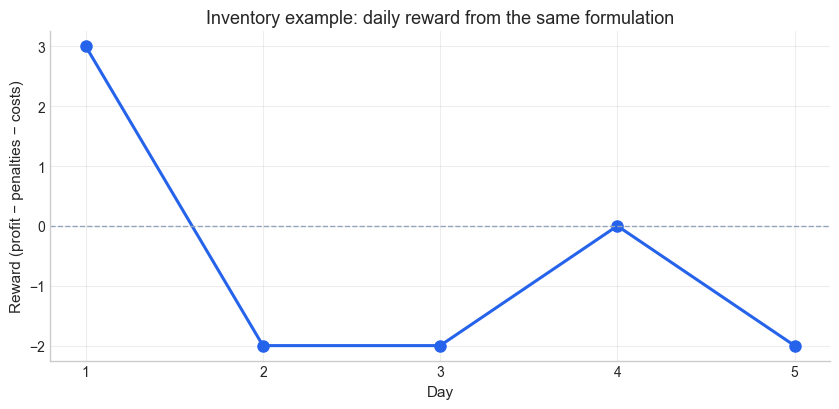


Teaching point:
This example is not about advanced RL yet.
It is about translating a real problem into states, actions, and rewards.


In [7]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# Save a value in a name so the next lines can read it.
MAX_STOCK = 10
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = {0: "do not reorder", 1: "reorder 5 units"}


# Function `inventory_step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def inventory_step(state, action):
    # Save a value in a name so the next lines can read it.
    stock = min(state + (5 if action == 1 else 0), MAX_STOCK)
    # Another assignment—same idea: store a value for the lines below.
    demand = np.random.randint(0, 4)
    # Another assignment—same idea: store a value for the lines below.
    sold = min(stock, demand)
    # Another assignment—same idea: store a value for the lines below.
    shortage_penalty = 2 if demand > stock else 0
    # Another assignment—same idea: store a value for the lines below.
    reorder_cost = 0.5 if action == 1 else 0.0
    # Unpack the one-step model output from transition(state, action).
    reward = sold - shortage_penalty - reorder_cost
    # Unpack the one-step model output from transition(state, action).
    next_state = max(stock - demand, 0)
    # Send a value back to whoever called this function.
    return next_state, reward, demand


# Create or choose a variable used in the Bellman warm-up demo.
state = 3
# Show text or numbers in the cell output area under the code.
print("Starting stock level:", state)
# Collect daily rewards for a simple line chart.
inventory_rewards = []
# Start a loop: repeat the indented block once per item in the sequence.
for day in range(5):
    # Save a value in a name so the next lines can read it.
    action = np.random.randint(0, 2)
    # Unpack the one-step model output from transition(state, action).
    next_state, reward, demand = inventory_step(state, action)
    # Add one new item to the end of a list (the list grows in place).
    inventory_rewards.append(float(reward))
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"Day {day + 1}: action='{ACTIONS[action]}', demand={demand}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"next_state={next_state}, reward={reward:.1f}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )
    # Create or choose a variable used in the Bellman warm-up demo.
    state = next_state

fig, ax = plt.subplots(figsize=(8.5, 4.2))
days = np.arange(1, len(inventory_rewards) + 1)
ax.plot(days, inventory_rewards, marker="o", linewidth=2.2, markersize=8, color="#2563eb")
ax.axhline(0.0, color="#94a3b8", linestyle="--", linewidth=1)
ax.set_xticks(days)
ax.set_xlabel("Day")
ax.set_ylabel("Reward (profit − penalties − costs)")
ax.set_title("Inventory example: daily reward from the same formulation")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("This example is not about advanced RL yet.")
# Show text or numbers in the cell output area under the code.
print("It is about translating a real problem into states, actions, and rewards.")


## 💬 Discuss

Part 4 ran three action rules on one FrozenLake map: random actions scored **0.0**, the hand-built
path reached the goal for **1.0**, always-LEFT stalled. Part 3 listed three reward designs. Argue
these out.

1. Take the maze reward from Part 3: `+10` goal, `−1` per move, `−10` trap. Try to break it. Is
   there any environment layout where an agent maximising that reward does something the designer
   would call wrong? (Hint: what if the trap is unavoidable on every route, or if there is a corner
   the agent can sit in?)
2. CartPole pays `+1` per balanced step. That is a reward for *not failing*. Name a real system where
   "reward the absence of failure" is the right design, and one where it would produce a machine that
   does nothing at all rather than risk anything.
3. The inventory example prints a reward of `profit − cost − shortage`. Suppose a Saudi retailer tells
   you that a stock-out during Ramadan damages the brand for a year, far beyond that day's lost
   margin. How would you put that into a per-step reward — and what would you say to a colleague who
   argues it belongs in the *state* instead, not the reward?


## Summary

The main lesson of this notebook is that RL problem design comes before RL algorithms.

### Remember

- **State** should contain useful decision information.
- **Action** should reflect the real choices available to the agent.
- **Reward** should align with the real goal, not a shortcut.
- **Simulation** is how we test whether our formulation behaves sensibly.

### Common mistake to avoid

A reward can be mathematically clear but educationally wrong if it teaches the wrong behavior.

### Next step

Move to `07_mini_projects_cartpole_frozenlake_qlearning_dqn.ipynb` to connect these design ideas to simple applied examples.

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
# This must stay a CODE cell (not Markdown). If Run All fails here, reload the notebook from disk.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 1 and Ch. 3 — states, actions, rewards.
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. Silver, D., Huang, A., Maddison, C. J. et al. (2016). *Mastering the game of Go with deep neural networks and tree search* (AlphaGo). Nature, 529, 484-489. <https://www.nature.com/articles/nature16961>
4. Towers, M., Kwiatkowski, A., Terry, J. et al. (2024). *Gymnasium: A Standard Interface for Reinforcement Learning Environments*. arXiv:2407.17032. <https://arxiv.org/abs/2407.17032>
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 1 and Ch. 3 — states, actions, rewards.
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. Silver, D., Huang, A., Maddison, C. J. et al. (2016). *Mastering the game of Go with deep neural networks and tree search* (AlphaGo). Nature, 529, 484-489. <https://www.nature.com/articles/nature16961>
4. Towers, M., Kwiatkowski, A., Terry, J. et al. (2024). *Gymnasium: A Standard Interface for Reinforcement Learning Environments*. arXiv:2407.17032. <https://arxiv.org/abs/2407.17032>


## ⚠️ Where this breaks

**The assumption that has to hold:** the reward you can measure is a faithful stand-in for the
outcome you actually want. It usually is not, and the gap is where RL projects die.

- **Proxies get gamed, and the better your agent, the faster.** Targets-hit instead of race-finished.
  Watch-time instead of satisfaction. Clicks instead of trust. A weak agent leaves a bad proxy alone
  because it cannot find the exploit; a strong one finds it in hours. Improving the algorithm makes
  this failure *worse*, not better.
- **Shaping bonuses change the optimal policy unless you are careful.** The bicycle case above is the
  canonical example. Ng, Harada and Russell (ICML 1999) proved that a shaping term written as a
  difference of a potential function, `F = γΦ(s') − Φ(s)`, leaves the optimal policy untouched — and
  that arbitrary "helpful" bonuses do not. Unit 3, lesson 06 implements the safe form; anything else
  is a new reward function wearing a disguise.
- **The state can be too small as well as too large.** Part 1's table calls "stock level from
  yesterday only" too small. If the information needed to act well is missing from the state, no
  reward design and no algorithm can recover it — the agent is being asked a question it cannot see.
- **Sparse honest rewards are hard; dense convenient rewards are dangerous.** That is the real
  trade-off, and it has no general solution. What exists is a habit: after training, look at *what
  the agent actually does*, not at the reward curve. The curve was always going to go up.
- **Cheaper alternative:** when the desired behaviour is already known and writable — "restock when
  stock drops below k", "alert when both aircraft are converging" — write the rule, measure it, and
  keep RL in reserve for the case where nobody can write the rule down. A rule that is 90% as good
  and fully inspectable often wins the meeting, and sometimes it should.


## Closing Takeaway

**Teaching takeaway:** Good RL work begins with problem formulation: choosing a useful state, a realistic action space, and a reward that matches the real goal.

**If students remember one idea:** Many RL failures come from poor problem definition, not from the algorithm itself.

**Quick check before moving on:**
- Can you redesign a bad reward so it better reflects the true objective?
- Can you explain why missing state information can make learning impossible?

**Bridge to the next step:** The mini-project lesson shows how these design choices appear in practical RL experiments.

**For weaker coders:** Pick one story (robot, game, trading). Write state, action, and reward as one plain English sentence each—if you can, you are doing RL design correctly.
